In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('application_train.csv')

# Basic Checks

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [5]:
df.shape

(307511, 122)

In [6]:
df.size

37516342

In [7]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [8]:
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

# Handling Missing values or Null values

In [9]:
df.AMT_REQ_CREDIT_BUREAU_DAY=df.AMT_REQ_CREDIT_BUREAU_DAY.fillna(df.AMT_REQ_CREDIT_BUREAU_DAY.median())

In [10]:
df.AMT_REQ_CREDIT_BUREAU_DAY .isnull().sum()

np.int64(0)

In [11]:
df.AMT_REQ_CREDIT_BUREAU_WEEK=df.AMT_REQ_CREDIT_BUREAU_WEEK.fillna(df.AMT_REQ_CREDIT_BUREAU_WEEK.median())

In [12]:
df.AMT_REQ_CREDIT_BUREAU_WEEK.isnull().sum()

np.int64(0)

In [13]:
df.AMT_REQ_CREDIT_BUREAU_MON=df.AMT_REQ_CREDIT_BUREAU_MON.fillna(df.AMT_REQ_CREDIT_BUREAU_MON .median())

In [14]:
df.AMT_REQ_CREDIT_BUREAU_MON .isnull().sum()

np.int64(0)

In [15]:
df.AMT_REQ_CREDIT_BUREAU_QRT=df.AMT_REQ_CREDIT_BUREAU_QRT.fillna(df.AMT_REQ_CREDIT_BUREAU_QRT.median())

In [16]:
df.AMT_REQ_CREDIT_BUREAU_QRT.isnull().sum()

np.int64(0)

In [17]:
df.AMT_REQ_CREDIT_BUREAU_YEAR=df.AMT_REQ_CREDIT_BUREAU_YEAR.fillna(df.AMT_REQ_CREDIT_BUREAU_YEAR.median())

In [18]:
df.AMT_REQ_CREDIT_BUREAU_YEAR.isnull().sum()

np.int64(0)

In [19]:
df.isnull().sum()

SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 122, dtype: int64

# Separate the Independent Features and Dependent Feature

In [20]:
x=df.drop('TARGET',axis=1)

In [21]:
x

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,0.0,0.0,0.0,0.0,1.0
4,100007,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,...,0,0,0,0,NaN,0.0,0.0,0.0,0.0,1.0
307507,456252,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,...,0,0,0,0,NaN,0.0,0.0,0.0,0.0,1.0
307508,456253,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
y=df.TARGET

In [23]:
y

0         1
1         0
2         0
3         0
4         0
         ..
307506    0
307507    0
307508    0
307509    1
307510    0
Name: TARGET, Length: 307511, dtype: int64

In [24]:
df.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

# Encoding Technique

In [25]:
from sklearn.preprocessing import OneHotEncoder
df1=pd.get_dummies(df.NAME_CONTRACT_TYPE,prefix="OHE",dtype='int',drop_first=True)
df1

,OHE_Revolving loans
0,0
1,0
2,1
3,0
4,0
...,...
307506,0
307507,0
307508,0
307509,0


In [26]:
df=pd.concat([df,df1],axis=1).drop(['NAME_CONTRACT_TYPE'],axis=1)

In [27]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       ...
       'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
       'OHE_Revolving loans'],
      dtype='object', length=122)

In [28]:
from sklearn.preprocessing import OneHotEncoder
df2=pd.get_dummies(df.CODE_GENDER ,prefix='GD',dtype='int',drop_first=True)
df2

,GD_M,GD_XNA
0,1,0
1,0,0
2,1,0
3,0,0
4,1,0
...,...,...
307506,1,0
307507,0,0
307508,0,0
307509,0,0


In [29]:
df=pd.concat([df,df2],axis=1).drop('CODE_GENDER',axis=1)

In [30]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       ...
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'OHE_Revolving loans', 'GD_M', 'GD_XNA'],
      dtype='object', length=123)

In [31]:
df3=pd.get_dummies(df.FLAG_OWN_CAR ,prefix="car",dtype="int",drop_first=True)
df3

,car_Y
0,0
1,0
2,1
3,0
4,0
...,...
307506,0
307507,0
307508,0
307509,0


In [32]:
df=pd.concat([df,df3],axis=1).drop('FLAG_OWN_CAR',axis=1)

In [33]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
       ...
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
       'OHE_Revolving loans', 'GD_M', 'GD_XNA', 'car_Y'],
      dtype='object', length=123)

In [34]:
df.dtypes

SK_ID_CURR                      int64
TARGET                          int64
FLAG_OWN_REALTY                object
CNT_CHILDREN                    int64
AMT_INCOME_TOTAL              float64
                               ...   
AMT_REQ_CREDIT_BUREAU_YEAR    float64
OHE_Revolving loans             int64
GD_M                            int64
GD_XNA                          int64
car_Y                           int64
Length: 123, dtype: object

In [35]:
df4=pd.get_dummies(df.FLAG_OWN_REALTY,prefix="FOR",dtype="int",drop_first=True)
df4

,FOR_Y
0,1
1,0
2,1
3,1
4,1
...,...
307506,0
307507,1
307508,1
307509,1


In [36]:
df=pd.concat([df,df4],axis=1).drop('FLAG_OWN_REALTY',axis=1)

In [37]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       ...
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'OHE_Revolving loans', 'GD_M', 'GD_XNA',
       'car_Y', 'FOR_Y'],
      dtype='object', length=123)

In [38]:
df.dtypes

SK_ID_CURR               int64
TARGET                   int64
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
AMT_CREDIT             float64
                        ...   
OHE_Revolving loans      int64
GD_M                     int64
GD_XNA                   int64
car_Y                    int64
FOR_Y                    int64
Length: 123, dtype: object

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 123 entries, SK_ID_CURR to FOR_Y
dtypes: float64(65), int64(46), object(12)
memory usage: 288.6+ MB


In [40]:
df.describe(include="object")

,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,306219,307511,307511,307511,307511,211120,307511,307511,97216,153214,151170,161756
unique,7,8,5,6,6,18,7,58,4,3,7,2
top,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,248526,158774,218391,196432,272868,55186,53901,67992,73830,150503,66040,159428


In [41]:
df5=pd.get_dummies(df.NAME_TYPE_SUITE,dtype="int",drop_first=True)
df=pd.concat([df,df5],axis=1).drop('NAME_TYPE_SUITE',axis=1)


In [42]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       ...
       'GD_M', 'GD_XNA', 'car_Y', 'FOR_Y', 'Family', 'Group of people',
       'Other_A', 'Other_B', 'Spouse, partner', 'Unaccompanied'],
      dtype='object', length=128)

In [43]:
df6=pd.get_dummies(df.NAME_INCOME_TYPE,dtype="int",drop_first=True)
df=pd.concat([df,df6],axis=1).drop('NAME_INCOME_TYPE',axis=1)


In [44]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       ...
       'Other_B', 'Spouse, partner', 'Unaccompanied', 'Commercial associate',
       'Maternity leave', 'Pensioner', 'State servant', 'Student',
       'Unemployed', 'Working'],
      dtype='object', length=134)

In [45]:
df7=pd.get_dummies(df.NAME_EDUCATION_TYPE,dtype="int",drop_first=True)
df=pd.concat([df,df7],axis=1).drop('NAME_EDUCATION_TYPE',axis=1)


In [46]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE',
       ...
       'Maternity leave', 'Pensioner', 'State servant', 'Student',
       'Unemployed', 'Working', 'Higher education', 'Incomplete higher',
       'Lower secondary', 'Secondary / secondary special'],
      dtype='object', length=137)

In [47]:
df8=pd.get_dummies(df.NAME_FAMILY_STATUS,dtype="int",drop_first=True)
df=pd.concat([df,df8],axis=1).drop('NAME_FAMILY_STATUS',axis=1)


In [48]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_HOUSING_TYPE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       ...
       'Working', 'Higher education', 'Incomplete higher', 'Lower secondary',
       'Secondary / secondary special', 'Married', 'Separated',
       'Single / not married', 'Unknown', 'Widow'],
      dtype='object', length=141)

In [49]:
df9=pd.get_dummies(df.NAME_HOUSING_TYPE,dtype="int",drop_first=True)
df=pd.concat([df,df9],axis=1).drop('NAME_HOUSING_TYPE',axis=1)


In [50]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'Married', 'Separated', 'Single / not married', 'Unknown', 'Widow',
       'House / apartment', 'Municipal apartment', 'Office apartment',
       'Rented apartment', 'With parents'],
      dtype='object', length=145)

In [51]:
df10=pd.get_dummies(df.OCCUPATION_TYPE,dtype="int",drop_first=True)
df=pd.concat([df,df10],axis=1).drop('OCCUPATION_TYPE',axis=1)


In [52]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'Laborers', 'Low-skill Laborers', 'Managers', 'Medicine staff',
       'Private service staff', 'Realty agents', 'Sales staff', 'Secretaries',
       'Security staff', 'Waiters/barmen staff'],
      dtype='object', length=161)

In [53]:
df11=pd.get_dummies(df.WEEKDAY_APPR_PROCESS_START,dtype="int",drop_first=True)
df=pd.concat([df,df11],axis=1).drop('WEEKDAY_APPR_PROCESS_START',axis=1)


In [54]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'Sales staff', 'Secretaries', 'Security staff', 'Waiters/barmen staff',
       'MONDAY', 'SATURDAY', 'SUNDAY', 'THURSDAY', 'TUESDAY', 'WEDNESDAY'],
      dtype='object', length=166)

In [55]:
df12=pd.get_dummies(df.ORGANIZATION_TYPE,dtype="int",drop_first=True)
df=pd.concat([df,df12],axis=1).drop('ORGANIZATION_TYPE',axis=1)


In [56]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'Trade: type 4', 'Trade: type 5', 'Trade: type 6', 'Trade: type 7',
       'Transport: type 1', 'Transport: type 2', 'Transport: type 3',
       'Transport: type 4', 'University', 'XNA'],
      dtype='object', length=222)

In [57]:
df13=pd.get_dummies(df.FONDKAPREMONT_MODE,dtype="int",drop_first=True)
df=pd.concat([df,df13],axis=1).drop('FONDKAPREMONT_MODE',axis=1)


In [58]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'Trade: type 7', 'Transport: type 1', 'Transport: type 2',
       'Transport: type 3', 'Transport: type 4', 'University', 'XNA',
       'org spec account', 'reg oper account', 'reg oper spec account'],
      dtype='object', length=224)

In [59]:
df14=pd.get_dummies(df.HOUSETYPE_MODE,dtype="int",drop_first=True)
df=pd.concat([df,df14],axis=1).drop('HOUSETYPE_MODE',axis=1)


In [60]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'Transport: type 2', 'Transport: type 3', 'Transport: type 4',
       'University', 'XNA', 'org spec account', 'reg oper account',
       'reg oper spec account', 'specific housing', 'terraced house'],
      dtype='object', length=225)

In [61]:
df15=pd.get_dummies(df.WALLSMATERIAL_MODE,dtype="int",drop_first=True)
df=pd.concat([df,df15],axis=1).drop('WALLSMATERIAL_MODE',axis=1)


In [62]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'reg oper account', 'reg oper spec account', 'specific housing',
       'terraced house', 'Mixed', 'Monolithic', 'Others', 'Panel',
       'Stone, brick', 'Wooden'],
      dtype='object', length=230)

In [63]:
df15=pd.get_dummies(df.EMERGENCYSTATE_MODE,dtype="int",drop_first=True)
df=pd.concat([df,df15],axis=1).drop('EMERGENCYSTATE_MODE',axis=1)


In [64]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'reg oper spec account', 'specific housing', 'terraced house', 'Mixed',
       'Monolithic', 'Others', 'Panel', 'Stone, brick', 'Wooden', 'Yes'],
      dtype='object', length=230)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 230 entries, SK_ID_CURR to Yes
dtypes: float64(65), int64(165)
memory usage: 539.6 MB


# Display the maximum columns

In [66]:
#x_train

In [71]:
# display the specific datatypes using select_dtype() method

cat_cols=x_train.select_dtypes(include='object').columns

In [72]:
cat_cols

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [73]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='most_frequent')
x_train[cat_cols]=si.fit_transform(x_train[cat_cols])

In [74]:
type(x_train)

pandas.core.frame.DataFrame

In [75]:
x_train.NAME_CONTRACT_TYPE=x_train.NAME_CONTRACT_TYPE.map({'Cash loans':1})


In [76]:
x_train.NAME_CONTRACT_TYPE

207148    1.0
292701    1.0
113750    1.0
119989    1.0
262074    1.0
         ... 
258063    1.0
167544    1.0
127353    1.0
49315     1.0
81853     1.0
Name: NAME_CONTRACT_TYPE, Length: 230633, dtype: float64

In [77]:
x_train.CODE_GENDER=x_train.CODE_GENDER.map({'M':1,'F':0})

In [78]:
x_train.FLAG_OWN_CAR=x_train.FLAG_OWN_CAR.map({'Y':1,'N':0})	

In [79]:
x_train.FLAG_OWN_REALTY=x_train.FLAG_OWN_REALTY.map({'Y':1,'N':0})

In [80]:
x_train.FLAG_OWN_CAR

207148    1
292701    0
113750    0
119989    0
262074    0
         ..
258063    1
167544    0
127353    0
49315     1
81853     0
Name: FLAG_OWN_CAR, Length: 230633, dtype: int64

In [81]:
x_train.FLAG_OWN_REALTY

207148    1
292701    0
113750    1
119989    1
262074    0
         ..
258063    1
167544    1
127353    0
49315     1
81853     1
Name: FLAG_OWN_REALTY, Length: 230633, dtype: int64

In [82]:
x_train_scaled=x_train.select_dtypes(include='int').drop(['FLAG_OWN_CAR','FLAG_OWN_REALTY'],axis=1)

In [83]:
x_train_scaled

,SK_ID_CURR,CNT_CHILDREN,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
207148,340106,0,-23286,365243,-4356,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
292701,439093,0,-17369,-352,-912,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
113750,231920,0,-10165,-1141,-2829,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
119989,239138,0,-14659,-540,-3776,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
262074,403357,1,-11168,-4548,-3643,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258063,398635,1,-13601,-3442,-4656,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
167544,294223,0,-23279,365243,-4112,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
127353,247692,2,-10969,-2119,-3629,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
49315,157087,0,-13489,-1721,-5130,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [84]:
x_test_scaled=x_test.select_dtypes(include='int')

In [85]:
x_test_scaled

,SK_ID_CURR,CNT_CHILDREN,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
179042,307474,0,-19842,-3001,-2278,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
269683,412537,0,-16820,-445,-355,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
42405,149084,0,-16078,-1273,-4126,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
228527,364692,2,-13434,-4101,-3253,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
47854,155423,0,-21702,-4388,-5085,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75554,187616,1,-14142,-546,-3899,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
260070,400955,1,-15009,-1007,-4351,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
57189,166285,1,-8811,-852,-1056,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
301090,448822,0,-18228,-5416,-1681,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


# EDA(Exploratory Data Analysis)

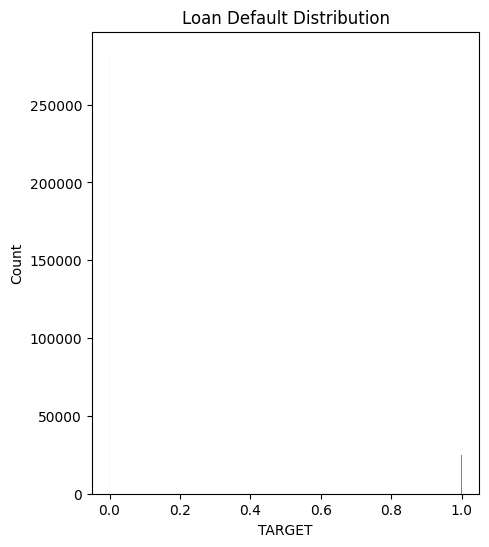

In [94]:
plt.figure(figsize=(5,6))
sns.histplot(x='TARGET',data=df)
plt.title("Loan Default Distribution")
plt.show()

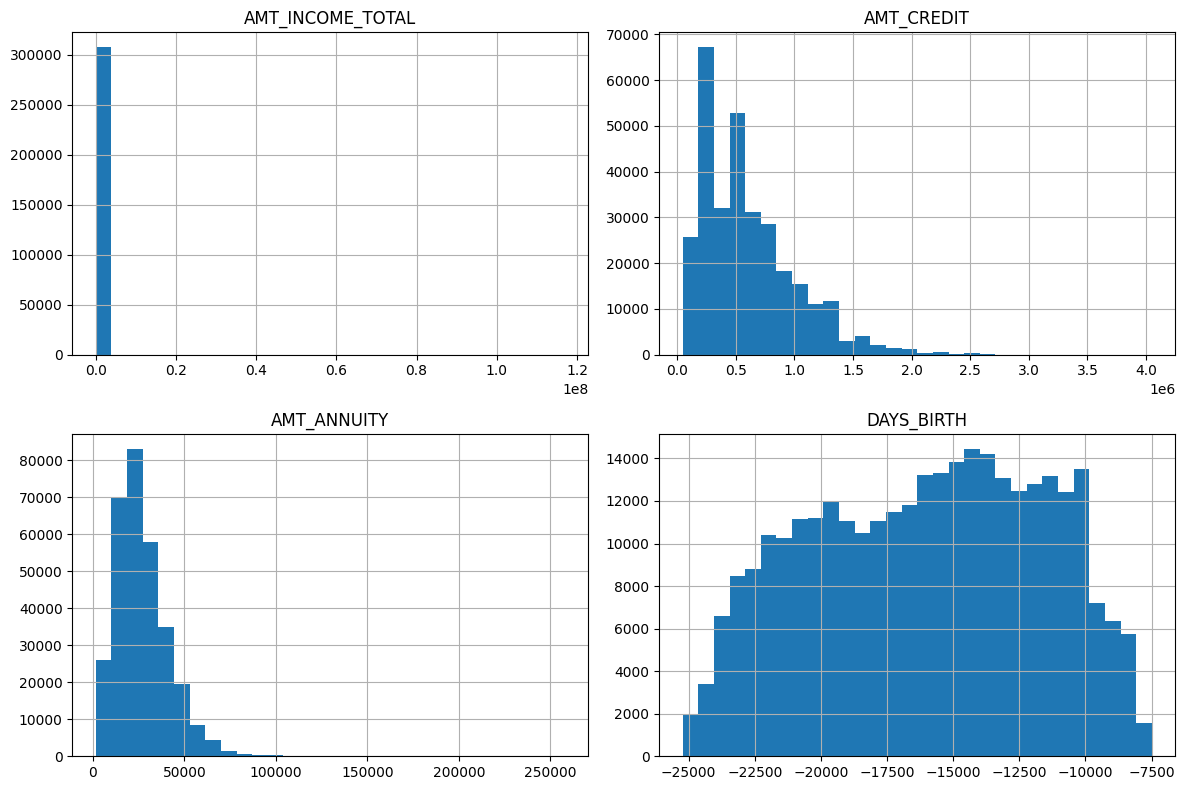

In [95]:
num_cols = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','DAYS_BIRTH']

df[num_cols].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

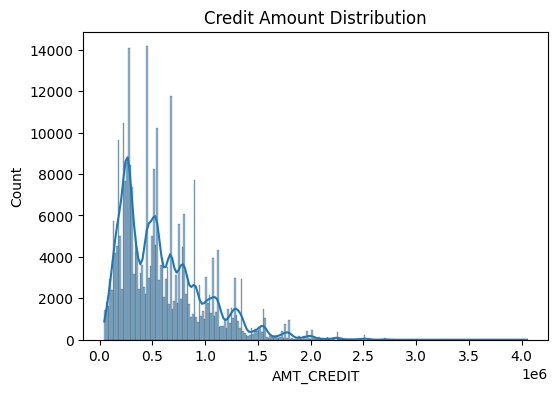

In [96]:
plt.figure(figsize=(6,4))
sns.histplot(df['AMT_CREDIT'], kde=True)
plt.title("Credit Amount Distribution")
plt.show()

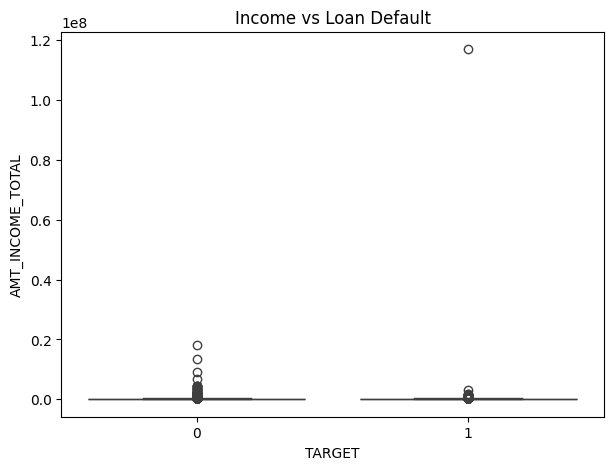

In [97]:
plt.figure(figsize=(7,5))
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)
plt.title("Income vs Loan Default")
plt.show()

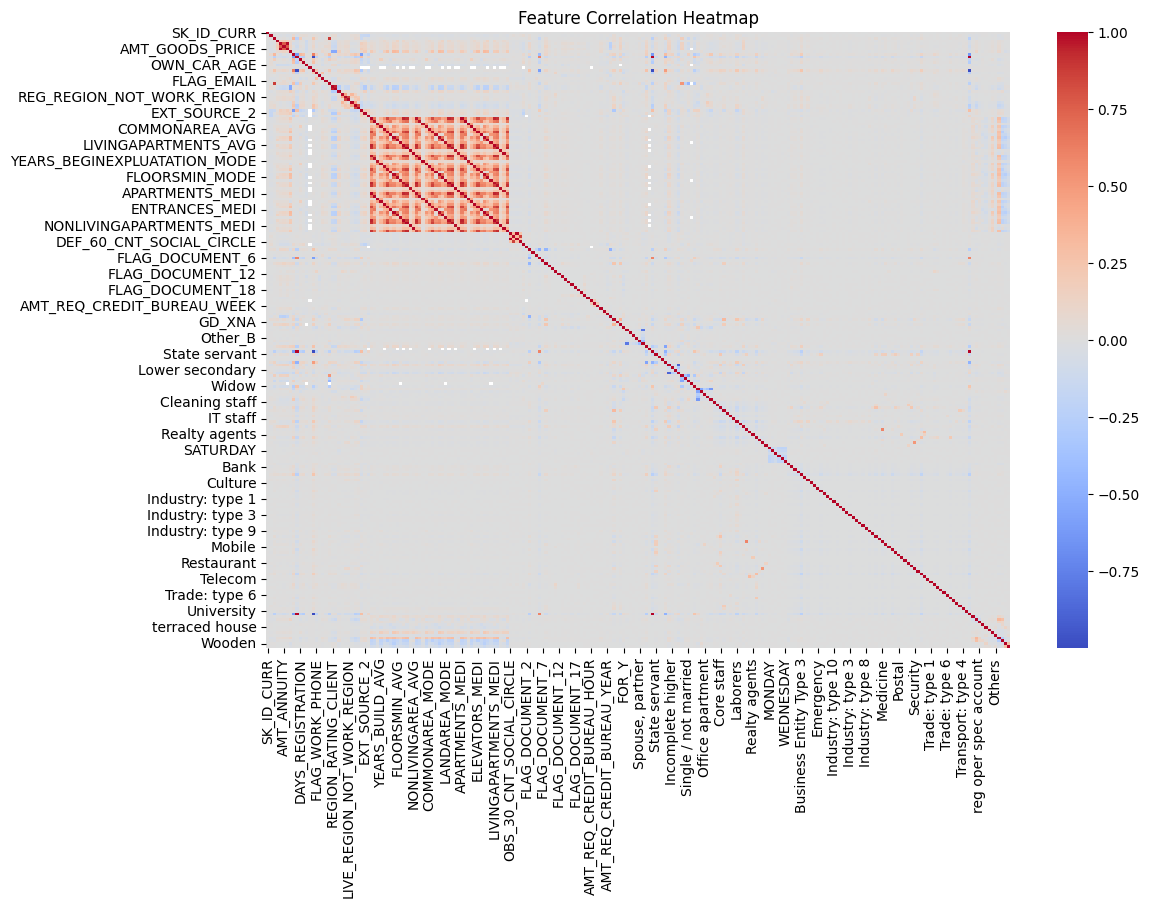

In [99]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Split the Train-Test Data

In [70]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=45)

# Feature Selection

In [ ]:
x_train_scaled

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaler=sc.fit(x_train_scaled)
x_test_scaler=sc.transform(x_test_scaled)

# Model Creation

In [105]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=100)
model_lr=lr.fit(x_train_scaled,y_train)


C:\Users\tauff\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [106]:
y_predict_lr=model_lr.predict(x_test_scaled)

In [107]:
y_predict_lr

array([0, 0, 0, ..., 0, 0, 0], shape=(76878,))

In [108]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(max_depth=7)
model_dtc=dtc.fit(x_train_scaled,y_train)

In [109]:
y_predict_dtc=model_dtc.predict(x_test_scaled)

In [110]:
y_predict_dtc

array([0, 0, 0, ..., 0, 0, 0], shape=(76878,))

In [111]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=85,n_jobs=-1)
model_rfc=rfc.fit(x_train_scaled,y_train)

In [112]:
y_predict_rfc=model_rfc.predict(x_test_scaled)

In [113]:
y_predict_rfc

array([0, 0, 0, ..., 0, 0, 0], shape=(76878,))

# Evaluation the Model

In [114]:
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score,classification_report

In [115]:
acu=accuracy_score(y_test,y_predict_lr)

In [116]:
print("Accuracy Score is =",acu)

Accuracy Score is = 0.9196519160227894


In [117]:
roc_auc=roc_auc_score(y_test,y_predict_lr)

In [118]:
print("Receiver Operating Characteristic and Area Under the Curve is =",roc_auc)

Receiver Operating Characteristic and Area Under the Curve is = 0.5


In [119]:
cm=confusion_matrix(y_test,y_predict_lr)

In [120]:
print("Confusion Matrix is =",cm)

Confusion Matrix is = [[70701     0]
 [ 6177     0]]


In [121]:
cr=classification_report(y_test,y_predict_lr)

C:\Users\tauff\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tauff\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tauff\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [122]:
print("Classification Report =",cr)

Classification Report =               precision    recall  f1-score   support

           0       0.92      1.00      0.96     70701
           1       0.00      0.00      0.00      6177

    accuracy                           0.92     76878
   macro avg       0.46      0.50      0.48     76878
weighted avg       0.85      0.92      0.88     76878



In [123]:
acu=accuracy_score(y_test,y_predict_dtc)

In [124]:
print("Accuracy Score is =",acu)

Accuracy Score is = 0.919339733083587


In [125]:
roc_auc=roc_auc_score(y_test,y_predict_dtc)

In [126]:
print("Receiver Operating Characteristic and Area Under the Curve is =",roc_auc)

Receiver Operating Characteristic and Area Under the Curve is = 0.5001996381769277


In [127]:
cm=confusion_matrix(y_test,y_predict_dtc)

In [128]:
print("Confusion Matrix is =",cm)

Confusion Matrix is = [[70672    29]
 [ 6172     5]]


In [129]:
cr=classification_report(y_test,y_predict_dtc)

In [130]:
print("Classification Report =",cr)

Classification Report =               precision    recall  f1-score   support

           0       0.92      1.00      0.96     70701
           1       0.15      0.00      0.00      6177

    accuracy                           0.92     76878
   macro avg       0.53      0.50      0.48     76878
weighted avg       0.86      0.92      0.88     76878



In [131]:
acu=accuracy_score(y_test,y_predict_rfc)

In [132]:
print("Accuracy Score is =",acu)

Accuracy Score is = 0.9195868779104556


In [133]:
roc_auc=roc_auc_score(y_test,y_predict_rfc)

In [134]:
print("Receiver Operating Characteristic and Area Under the Curve is =",roc_auc)

Receiver Operating Characteristic and Area Under the Curve is = 0.5002601334492803


In [135]:
cm=confusion_matrix(y_test,y_predict_rfc)

In [136]:
print("Confusion Matrix is =",cm)

Confusion Matrix is = [[70692     9]
 [ 6173     4]]


In [137]:
cr=classification_report(y_test,y_predict_rfc)

In [138]:
print("Classification Report =",cr)

Classification Report =               precision    recall  f1-score   support

           0       0.92      1.00      0.96     70701
           1       0.31      0.00      0.00      6177

    accuracy                           0.92     76878
   macro avg       0.61      0.50      0.48     76878
weighted avg       0.87      0.92      0.88     76878



# Project Report

## 1.Executive Summary
#### This project focuses on predicting home loan default risk using machine learning classification techniques. The objective is to help financial institutions identify whether a loan applicant is likely to default based on historical customer and loan-related data.

#### The dataset contains multiple borrower attributes such as income level, credit behavior, loan characteristics, and demographic information. A complete data science pipeline was implemented including data preprocessing, handling missing values, feature encoding, model building, and performance evaluation.

#### Multiple classification algorithms were tested, including Logistic Regression, Decision Tree, and Random Forest classifiers. Among them, the Random Forest model achieved the best predictive performance, demonstrating strong capability in identifying high-risk borrowers.

#### The final model provides a reliable decision-support system for loan risk assessment and credit approval.



## 2.Problem Statement

#### The objectives of this project are:
#### • To analyze home loan applicant data
#### • To predict whether a customer will default on a loan
#### • To identify key factors influencing loan default risk
#### • To assist banks in reducing financial losses through data-driven decisions

# 3.Dataset Description
# The dataset includes borrower and loan-related information such as:
#### • Applicant income and financial status
#### • Loan amount and repayment details
#### • Credit history indicators
#### • Employment and demographic attributes
#### • Previous financial behavior
# Target Variable
#### Loan Default Status
#### 0 → Non-Default
#### 1 → Default
The dataset contains both numerical and categorical features.



# Complete Data Analysis Report
# 4.1 Data Understanding
#### • Presence of missing values in several columns
#### • Combination of categorical and numerical variables
#### • Class imbalance observed between default and non-default cases

# 4.2 Data Cleaning
#### • Handling missing values using suitable imputation methods
#### • Removing inconsistent or unnecessary columns
#### • Standardizing numerical features for better model performance
This ensured improved model stability and reduced noise.

# 4.3 Handling Missing Values
# Missing values were treated using:
#### • Mean/median imputation for numerical features
#### • Mode imputation for categorical variables
# Proper handling prevented bias and preserved dataset integrity.


# 4.4 Exploratory Data Analysis (EDA)
# EDA revealed several important insights:

#### • Applicants with lower income show higher default probability
#### • Higher loan amounts increase repayment risk
#### • Credit history strongly influences approval outcomes
#### • Stable employment reduces default likelihood
# Distribution analysis helped understand borrower behavior patterns.

# 4.5 Feature Engineering
# The following techniques were applied:
#### • Encoding categorical variables into numerical format
#### • Feature scaling using StandardScaler
#### • Train-test split for unbiased evaluation
#### • Feature selection to improve model efficiency

# 5. Robust Machine Learning Model
# Models Implemented
#### • Logistic Regression
#### • Decision Tree Classifier
#### • Random Forest Classifier
# Both linear and tree-based models were evaluated to capture different data relationships.

# Train-Test Split
The dataset was divided into training and testing sets to evaluate real-world performance and avoid overfitting.

# Model Evaluation Metrics
# Models were evaluated using:
#### • Accuracy Score
#### • Confusion Matrix
#### • ROC-AUC Score
#### • Precision, Recall, and F1-Score
# These metrics ensured balanced evaluation for classification problems.

# Final Model Performance (Conceptual Summary)
# Model	                    Performance Insight
#### Logistic Regression	      - Good baseline performance
#### Decision Tree	            - Captured nonlinear patterns but prone to overfitting
#### Random Forest	            - Highest accuracy and better generalization
Random Forest provided the most reliable predictions.

# Relationship Between Features and Loan Default
# Key Risk Drivers
#### • Applicant Income
#### • Loan Amount
#### • Credit History
#### • Employment Stability
#### • Financial Background
# Observations
#### • Poor credit history significantly increases default risk
#### • Higher loan burden leads to repayment difficulty
#### • Stable income reduces probability of default
#### • Financial discipline plays a major role in loan success

# Business Suggestions
For Banks and Financial Institutions
### • Prioritize applicants with strong credit history
#### • Carefully evaluate high loan-to-income ratios
#### • Introduce risk-based interest rates
#### • Monitor high-risk customers regularly

# For Loan Applicants
### • Maintain good credit score
### • Avoid excessive borrowing
### • Ensure stable income before applying
### • Maintain consistent repayment records

# Smart Risk Management Strategy
### • Use predictive analytics before loan approval
### • Combine ML predictions with manual verification
### • Monitor early warning signals for default risk



# Model Justification
Random Forest was selected as the final model because:
### • Handles nonlinear relationships effectively
### • Reduces overfitting through ensemble learning
### • Works well with mixed feature types
### • Provides strong predictive accuracy

# Challenges Faced During the Project
#### Handling Missing Data
Several variables contained null values requiring careful imputation.
#### Encoding Categorical Variables
Multiple categorical features required transformation without losing meaning.
### Class Imbalance
Default cases were fewer compared to non-default cases, affecting prediction balance.
### Overfitting Risk
Tree-based models initially showed high training performance.
### Feature Selection
Identifying meaningful predictors from many variables was challenging.

# How These Challenges Were Overcome
### • Proper preprocessing pipeline implemented
### • Feature scaling improved convergence
### • Ensemble learning reduced overfitting
### • Evaluation using multiple metrics ensured fairness
### • Structured experimentation identified the best model

# Future Scope
# Possible improvements include:
### • Applying advanced techniques like XGBoost or LightGBM
### • Using SMOTE for class imbalance handling
### • SHAP analysis for model explainability
### • Deployment as a loan approval web application
### • Integration with real-time banking systems

# Final Conclusion
#### This project successfully developed an end-to-end Home Loan Default Risk Prediction System using machine learning techniques.

#### Through systematic preprocessing, encoding, feature selection, and model evaluation, an effective classification model was built. Among all tested models, the Random Forest classifier achieved the best performance, demonstrating strong capability in identifying risky loan applicants.

#### The study confirms that credit history, income stability, and loan characteristics are the primary factors influencing loan default behavior.
#### This project highlights how machine learning can significantly improve decision-making in the banking and financial sector by minimizing risk and enhancing loan approval strategies.